# NNLS deconvolution of cell types

The goal of this notebook is to test the use of NNLS (non negative least squares) to deconvolve the cell type composition of a bulk mixture.
The input is a matrix containing one line per cell-type specific dmr regions and one column per target cell type:
at (i,j) the value is the mean probit for cell type j averaged on all the reads that overlap a dmr region specific to cell type i.

## 1. Import modules and set constants

In [ ]:
import os
import warnings
from contextlib import contextmanager

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pickle
import pandas as pd
import json
from tqdm.notebook import tqdm

import cvxpy as cp

from sklearn.base import (
    BaseEstimator,
    ClassifierMixin,
    MetaEstimatorMixin,
    RegressorMixin,
    clone,
)
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.metrics import accuracy_score


from EDA.edautils import plot_deconvolution_results
from methyldl.deconvolution.evaluation import compute_deconvolution_metrics_np
from methyldl.deconvolution.uxm import (
    load_atlas,
    uxm_deconvolution,
    rearange_uxm_deconvolution_results,
)

from methyldl.deconvolution.least_squares_deconvolvers import (
    PSLSDeconvolver,
    NNLSDeconvolver,
)

%load_ext autoreload
%autoreload 2

We are working on the methylation atlas from [Loyfer et al.](https://www.nature.com/articles/s41586-022-05580-6), with 39 cell types.

In [2]:
# mapping from cell type names to their corresponding labels in the dataset
with open("../App/labels_dict.json", "r") as f:
    labels_dict = json.load(f)
cell_type_to_label = {v: int(k) for k, v in labels_dict.items()}
N_CELL_TYPES = len(cell_type_to_label)

# constants for accessing the mixtures data
PRED_COLUMNS = [f"prediction_{i}_wavg" for i in range(N_CELL_TYPES)]
SPLIT_TO_IDX = {"train": 0, "val": 1, "test": 2}

## 2. Plotting and miscellaneous utilities

In [3]:
@contextmanager
def suppress_many_unique_classes_warning():
    """Suppresses the warning about having many unique classes in the dataset, which occurs when we train SVC with one sample per class."""
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            category=UserWarning,
            message=r"The number of unique classes is greater than 50% of the number of samples*",
        )
        yield

In [4]:
def softmax(logits: np.ndarray, T: float = 1) -> np.ndarray:
    """Compute the softmax of the logits with temperature scaling."""
    is_logits_1d = logits.ndim == 1
    if is_logits_1d:
        logits = logits.reshape(1, -1)
    scaled_logits = logits / T
    exp_scaled = np.exp(scaled_logits - np.max(scaled_logits, axis=1, keepdims=True))
    result = exp_scaled / np.sum(exp_scaled, axis=1, keepdims=True)
    if is_logits_1d:
        result = result.squeeze()
    return result

In [5]:
def plot_heatmap(
    matrix: np.ndarray,
    title: str = "Heatmap",
    color_bar_label: str = "Probability",
    vmin: float | None = None,
    vmax: float | None = None,
):
    """Plot a heatmap of the given matrix with cell type names on the axes."""
    plt.figure(figsize=(10, 8))
    plt.imshow(matrix, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(label=color_bar_label)
    plt.xticks(
        ticks=np.arange(matrix.shape[1]),
        labels=[labels_dict[str(i)] for i in range(matrix.shape[1])],
        rotation=90,
    )
    plt.yticks(
        ticks=np.arange(matrix.shape[0]),
        labels=[labels_dict[str(i)] for i in range(matrix.shape[0])],
    )
    plt.title(title)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.tight_layout()
    plt.show()

In [6]:
def plot_mixtures_pred_vs_true(
    ground_truth_mixture: np.ndarray,
    predicted_mixtures: list[np.ndarray],
    predicted_mixture_labels: list[str],
    width: float = 0.2,
    title: str = "Predicted Mixtures vs Ground Truth Mixture",
):
    """
    Plot the predicted mixtures against the ground truth mixture for a single sample.
    The function creates a bar plot where the x axis represents the cell types and the y axis represents the mixture proportions.
    Each predicted mixture is plotted as a separate bar. The ground truth mixture is plotted as red dots for each cell type.

    Args:
        ground_truth_mixture: A 1D array of shape (n_cell_types,) representing the true mixture proportions.
        predicted_mixtures: A list of 1D arrays, each of shape (n_cell_types,), representing the predicted mixture proportions from different models.
        predicted_mixture_labels: A list of strings representing the labels for each predicted mixture (e.g., model names).
    """
    assert len(predicted_mixtures) == len(
        predicted_mixture_labels
    ), "Number of predicted mixtures must match number of labels"
    assert all(
        pred.shape == ground_truth_mixture.shape for pred in predicted_mixtures
    ), "All predicted mixtures must have the same shape as the ground truth mixture"
    plt.figure(figsize=(8, 6))
    n_cell_types = len(ground_truth_mixture)
    n_predicted_mixtures = len(predicted_mixtures)
    x = np.arange(n_cell_types)  # start of the the label locations
    x_center = (
        x + width * (n_predicted_mixtures - 1) / 2
    )  # middle of the group of bars for each cell type

    # Plot the ground truth mixture as red dots
    plt.scatter(
        x_center, ground_truth_mixture, color="red", zorder=-1, label="Ground Truth"
    )

    # Plot each predicted mixture as a bar
    for i, (predicted_mixture, label) in enumerate(
        zip(predicted_mixtures, predicted_mixture_labels)
    ):
        plt.bar(x + i * width, predicted_mixture, width, label=label)

    # plot the cell types names on the x axis, rotated by 90 degrees
    plt.xticks(x_center, cell_type_to_label.keys(), rotation=90)
    plt.ylabel("Mixture Proportions")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

## 3. Data Loading

### 3.1. Pure mixtures

The file that we load in this section contains the input and output data related to the pure mixtures.

For every cell_type i:

- file[i][0] - Ground Truth proportions.
- file[i][1][k] - Pandas dataframes with aggregated predictions (k in 0,1,2 means train, validation and test datasets respectfully)
- file[i][2][k] - UXM input matrices and deconvolution results (k in 0,1,2 means train, validation and test datasets respectfully)

In [7]:
with open("../Data/mixtures/soft_labels_pure_ios.pkl", "rb") as f:
    soft_labels_pure_ios = pickle.load(f)

In [8]:
# functions to extract data from the loaded pickle file containing the pure mixtures and their corresponding predictions and ground truth labels
def get_pure_prediction_matrix(
    cell_type_name: int | str, split_name: str = "train"
) -> np.ndarray:
    if isinstance(cell_type_name, str):
        cell_type_label = cell_type_to_label[cell_type_name]
    else:
        cell_type_label = cell_type_name
    split_idx = SPLIT_TO_IDX[split_name]
    return soft_labels_pure_ios[cell_type_label][1][split_idx][PRED_COLUMNS].to_numpy()


def get_pure_uxm_results(
    cell_type_name: int | str, split_name: str = "train"
) -> pd.DataFrame:
    if isinstance(cell_type_name, str):
        cell_type_label = cell_type_to_label[cell_type_name]
    else:
        cell_type_label = cell_type_name
    split_idx = SPLIT_TO_IDX[split_name]
    return np.array(soft_labels_pure_ios[cell_type_label][2][split_idx][3])


def get_pure_ground_truth_mixture(cell_type_name: int | str) -> np.ndarray:
    if isinstance(cell_type_name, str):
        cell_type_label = cell_type_to_label[cell_type_name]
    else:
        cell_type_label = cell_type_name
    return np.array(soft_labels_pure_ios[cell_type_label][0])

### 3.2. Unpure mixtures

The file that we load in this section contains the input and output data related to the 1000 unpure mixtures.

The layout of the pkl is the same as for the pure mixtures, except that:

- the list contains 1000 tuples instead of 39
- the Ground Truth proportions are no longer one-hot vectors but rather vectors with 39 entries that sum to 1.
- the deconvolution *results* for UXM are not given and thus must be computed (the UXM *inputs* are given)

In [9]:
with open(
    "../Data/mixtures/ios_deconvolution_data_hg38_grouped_dmrs_uxm_alligned_1000.pkl",
    "rb",
) as f:
    unpure_mixtures_data = pickle.load(f)

In [10]:
# computing uxm deconvolution results for the unpure mixtures (if not already computed and saved in a pickle file)
file_uxm_unpure_results = (
    "../Data/mixtures/uxm_deconvolution_results_unpure_mixtures.pkl"
)
if os.path.exists(file_uxm_unpure_results):
    with open(file_uxm_unpure_results, "rb") as f:
        uxm_unpure_results = pickle.load(f)
    print(
        f"Loaded precomputed UxM deconvolution results for unpure mixtures from {file_uxm_unpure_results}"
    )
else:
    uxm_unpure_results = []
    uxm_atlas, uxm_ref_cells = load_atlas(
        "../Data/UXM_atlas/Atlas.U25.l4.hg38.full.tsv"
    )
    for mixture_idx in tqdm(range(len(unpure_mixtures_data))):
        uxm_unpure_results.append([])
        for split_idx in range(3):
            sf, counts = unpure_mixtures_data[mixture_idx][2][split_idx][:2]
            uxm_raw = uxm_deconvolution(
                atlas=uxm_atlas,
                ref_cells=uxm_ref_cells,
                sf=sf,
                counts=counts,
                sample_names=["pseudo_balk_sample"],
            )[0]
            uxm_aligned = np.array(
                rearange_uxm_deconvolution_results(
                    labels_dict_reversed=cell_type_to_label,
                    uxm_proportions=uxm_raw,
                    ref_cells=uxm_ref_cells,
                )
            )
            uxm_unpure_results[-1].append(uxm_aligned)
    with open(file_uxm_unpure_results, "wb") as f:
        pickle.dump(uxm_unpure_results, f)
    print(
        f"Saved UxM deconvolution results for unpure mixtures to {file_uxm_unpure_results}"
    )

Loaded precomputed UxM deconvolution results for unpure mixtures from ../Data/mixtures/uxm_deconvolution_results_unpure_mixtures.pkl


In [11]:
# functions to extract the unpure mixtures data from the loaded pickle file, which contains the predictions and ground truth labels for the unpure mixtures
def get_unpure_prediction_matrix(
    mixture_idx: int, split_name: str = "train"
) -> np.ndarray:
    split_idx = SPLIT_TO_IDX[split_name]
    return unpure_mixtures_data[mixture_idx][1][split_idx][PRED_COLUMNS].to_numpy()


def get_unpure_uxm_results(mixture_idx: int, split_name: str = "train") -> pd.DataFrame:
    split_idx = SPLIT_TO_IDX[split_name]
    return np.array(uxm_unpure_results[mixture_idx][split_idx])


def get_unpure_ground_truth_mixture(mixture_idx: int) -> np.ndarray:
    return np.array(unpure_mixtures_data[mixture_idx][0])

### 3.3 Mixtures with feature selection

In this section, we load a file with 100000 mixtures with feature selection. The features were selected based on whether feature.max()/feature.mean() > 1.1 where the statistics are computed on all mixtures in the union of the train and validation and test sets (yes, this is data leakage).

In [12]:
filename = "features_1.1_cutoff.npz"
filepath = f"../Data/mixtures/{filename}"
if os.path.exists(filepath):
    print(f"Loading feature-selected raw data from {filepath}")
    feature_selected_raw_data = np.load(filepath, allow_pickle=True)
else:
    print(
        f"Feature-selected raw data file not found at {filepath}. Please make sure the file exists."
    )

Loading feature-selected raw data from ../Data/mixtures/features_1.1_cutoff.npz


In [13]:
# find the indexes of the pure mixtures
pure_mixtures_indexes = []
for cell_type_idx in tqdm(range(N_CELL_TYPES)):
    for i, gr_proportions in enumerate(feature_selected_raw_data["proportions"]):
        if gr_proportions[cell_type_idx] == 1.0:
            pure_mixtures_indexes.append(i)
            break
    if i == len(feature_selected_raw_data["proportions"]) - 1:
        print(
            f"Warning: no pure mixture found for cell type {cell_type_idx} ({labels_dict[str(cell_type_idx)]})"
        )

  0%|          | 0/39 [00:00<?, ?it/s]

## 4. Data Preprocessing

Preprocessing of the data (essentially flattening the matrices)

In [14]:
# Preparation of the train, validation and test sets for the pure mixtures
def prepare_pure_X(split_name: str = "train"):
    X = np.array(
        [
            get_pure_prediction_matrix(cell_type_idx, split_name)
            for cell_type_idx in range(N_CELL_TYPES)
        ]
    )
    return X


y_pure = np.array(
    [
        get_pure_ground_truth_mixture(cell_type_idx)
        for cell_type_idx in range(N_CELL_TYPES)
    ]
)
# keep the original shape of the data
X_pure_train = prepare_pure_X("train")
X_pure_val = prepare_pure_X("val")
X_pure_test = prepare_pure_X("test")


# transform the targets to the cell type with the highest proportion in the ground truth mixture
y_pure_labels = np.argmax(y_pure, axis=1)

# flatten the matrices
X_pure_train_full = X_pure_train.reshape(X_pure_train.shape[0], -1)
X_pure_val_full = X_pure_val.reshape(X_pure_val.shape[0], -1)
X_pure_test_full = X_pure_test.reshape(X_pure_test.shape[0], -1)

X_pure_full_by_split = {
    "train": X_pure_train_full,
    "val": X_pure_val_full,
    "test": X_pure_test_full,
}

In [15]:
# Preparation of the train, validation and test sets for the unpure mixtures
def prepare_unpure_X(split_name: str = "train"):
    X = np.array(
        [
            get_unpure_prediction_matrix(mixture_idx, split_name)
            for mixture_idx in range(len(unpure_mixtures_data))
        ]
    )
    return X


y_unpure = np.array(
    [
        get_unpure_ground_truth_mixture(mixture_idx)
        for mixture_idx in range(len(unpure_mixtures_data))
    ]
)

# keep the original shape of the data
X_unpure_train = prepare_unpure_X("train")
X_unpure_val = prepare_unpure_X("val")
X_unpure_test = prepare_unpure_X("test")


# transform the targets to the cell type with the highest proportion in the ground truth mixture
y_unpure_labels = np.argmax(y_unpure, axis=1)

# flattens the matrices
X_unpure_train_full = X_unpure_train.reshape(X_unpure_train.shape[0], -1)
X_unpure_val_full = X_unpure_val.reshape(X_unpure_val.shape[0], -1)
X_unpure_test_full = X_unpure_test.reshape(X_unpure_test.shape[0], -1)

X_unpure_full_by_split = {
    "train": X_unpure_train_full,
    "val": X_unpure_val_full,
    "test": X_unpure_test_full,
}

In [16]:
# Preparation of the train, validation and test sets for the mixtures with feature selection
y_pure_ft_selected = np.array(
    [
        get_pure_ground_truth_mixture(cell_type_idx)
        for cell_type_idx in range(N_CELL_TYPES)
    ]
)
y_pure_labels_ft_selected = np.argmax(y_pure_ft_selected, axis=1)

y_all_ft_selected = feature_selected_raw_data["proportions"]

X_pure_ft_selected_by_split = {
    "train": feature_selected_raw_data["features_train"][pure_mixtures_indexes],
    "val": feature_selected_raw_data["features_valid"][pure_mixtures_indexes],
    "test": feature_selected_raw_data["features_test"][pure_mixtures_indexes],
}

X_all_ft_selected_by_split = {
    "train": feature_selected_raw_data["features_train"],
    "val": feature_selected_raw_data["features_valid"],
    "test": feature_selected_raw_data["features_test"],
}

## 5. Modeling

### 5.1 NNLS with 39 reference prediction matrices

The first idea we test is very simple: assuming that the unpure prediction matrices are linear combinations of the pure prediction matrices, we can directly apply NNLS to the unpure prediction matrices using the pure prediction matrices as reference.

In other terms, given an unpure prediction matrix $M$ of shape $(m, c)$ and $c$ pure prediction matrices $P_1, P_2, ..., P_c$, where $c$ is the number of cell types we want to solve the following optimization problem:

$$
\min_{\{w_i \ge 0\}_{1\leq i \leq c}} ||M - \sum_{i=1}^c w_i P_i||_F^2
$$

where $w_i$ is the proportion of cell type i in the unpure mixture and $||.||_F$ is the Frobenius norm.

We can reformulate this problem by flattening all the matrices and concatenating the pure prediction matrices into a single matrix $P$ of shape $(m*c, c)$ and the unpure prediction matrix $M$ into a vector of shape $(m*c, 1)$:

$$
\min_{w \in \mathbb{R}^c, w \ge 0} ||P w - M||_2^2
$$

#### 5.1.1. Implementation of the NNLS deconvolution method

#### 5.1.2. Evaluation of the NNLS deconvolution method on full matrices

In [17]:
nnls_deconvolver = NNLSDeconvolver()
_ = nnls_deconvolver.fit(X_pure_train_full, y_pure_labels)

Predicting with NNLS sequentially: 100%|██████████| 39/39 [00:00<00:00, 202.66it/s]


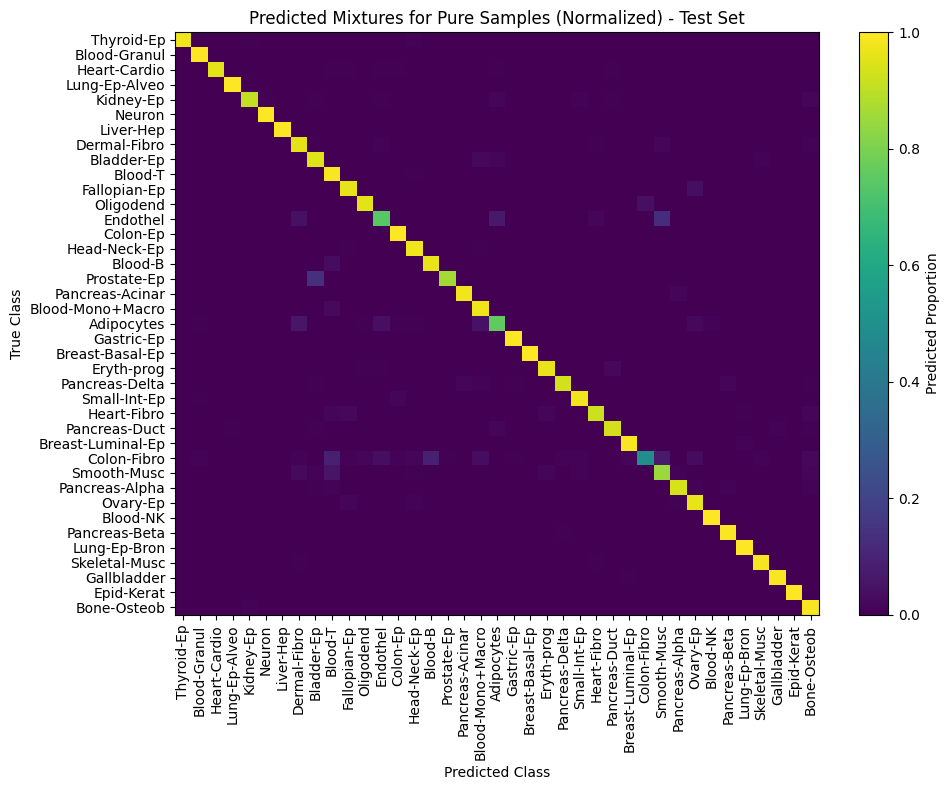

In [18]:
test_pure_preds, test_pure_preds_unnorm, test_pure_residuals = nnls_deconvolver.predict(
    X_pure_test_full
)
plot_heatmap(
    test_pure_preds,
    title="Predicted Mixtures for Pure Samples (Normalized) - Test Set",
    color_bar_label="Predicted Proportion",
    vmin=0,
    vmax=1,
)

So the performance looks really good on the test set for pure mixtures

In [19]:
# Comparison of the perf of NNLS and UXM on the unpure mixtures test set

test_unpure_preds, test_unpure_preds_unnorm, test_unpure_residuals = (
    nnls_deconvolver.predict(X_unpure_test_full, n_workers=1)
)
test_unpure_metrics = compute_deconvolution_metrics_np(
    pred=test_unpure_preds,
    target=y_unpure,
)

test_unpure_uxm_preds = np.array(
    [
        get_unpure_uxm_results(mixture_idx, "test")
        for mixture_idx in range(len(unpure_mixtures_data))
    ]
)
uxm_metrics = compute_deconvolution_metrics_np(
    pred=test_unpure_uxm_preds,
    target=y_unpure,
)

pd.DataFrame(
    {
        "NNLS": test_unpure_metrics,
        "UXM": uxm_metrics,
    },
    index=test_unpure_metrics.keys(),
)

Predicting with NNLS sequentially: 100%|██████████| 1000/1000 [00:07<00:00, 137.90it/s]


,NNLS,UXM
mae,0.003087,0.004698
mse,0.000146,0.000205
kl,0.075170,0.127817
max_error,0.513621,0.362574
cosine_sim,0.991723,0.991525


The performance on the whole unpure mixture dataset is better than UXM.

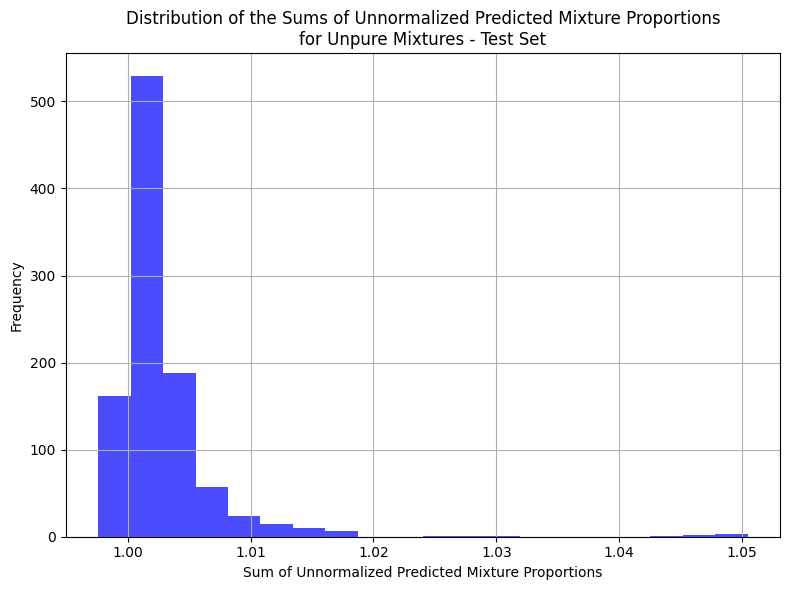

In [20]:
# Analysis of how hard the predictions had to be normalized to get good performance, by looking at the distribution of the sums of the unnormalized predicted mixture proportions across the samples in the test set of unpure mixtures
sums_unnorm_preds = test_unpure_preds_unnorm.sum(axis=1)
plt.figure(figsize=(8, 6))
plt.hist(sums_unnorm_preds, bins="rice", color="blue", alpha=0.7)
plt.xlabel("Sum of Unnormalized Predicted Mixture Proportions")
plt.ylabel("Frequency")
plt.title(
    "Distribution of the Sums of Unnormalized Predicted Mixture Proportions\nfor Unpure Mixtures - Test Set"
)
plt.grid()
plt.tight_layout()
plt.show()

#### 5.1.3. Evaluation of the NNLS deconvolution method on feature selected vectors

Now we evaluate the performance of the method on the whole dataset of 100, 000 unpure mixtures.

In [37]:
nnls_deconv_ft_selected = NNLSDeconvolver()
_ = nnls_deconv_ft_selected.fit(
    X_pure_ft_selected_by_split["train"], y_pure_labels_ft_selected
)

In [22]:
(
    pred_mixtures_nnls_ft_selected_test,
    pred_mixtures_unnormalized_nnls_ft_selected_test,
    fr_sel_test_residuals,
) = nnls_deconv_ft_selected.predict(X_all_ft_selected_by_split["test"], n_workers=1)

Predicting with NNLS sequentially: 100%|██████████| 100000/100000 [02:20<00:00, 713.19it/s]


In [23]:
(
    pred_mixtures_nnls_ft_selected_val,
    pred_mixtures_unnormalized_nnls_ft_selected_val,
    fr_sel_val_residuals,
) = nnls_deconv_ft_selected.predict(X_all_ft_selected_by_split["val"], n_workers=1)

Predicting with NNLS sequentially: 100%|██████████| 100000/100000 [01:38<00:00, 1016.44it/s]


In [24]:
# Comparison of the perf of NNLS and ? on the unpure mixtures test set
test_unpure_metrics_ft_selected = compute_deconvolution_metrics_np(
    pred=pred_mixtures_nnls_ft_selected_test, target=y_all_ft_selected
)
val_unpure_metrics_ft_selected = compute_deconvolution_metrics_np(
    pred=pred_mixtures_nnls_ft_selected_val, target=y_all_ft_selected
)


pd.DataFrame(
    {
        "NNLS test": test_unpure_metrics_ft_selected,
        "NNLS val": val_unpure_metrics_ft_selected,
    },
    index=test_unpure_metrics_ft_selected.keys(),
)

,NNLS test,NNLS val
mae,0.003294,0.003737
mse,0.000164,0.000183
kl,0.079957,0.088930
max_error,0.502844,0.405983
cosine_sim,0.991157,0.989830


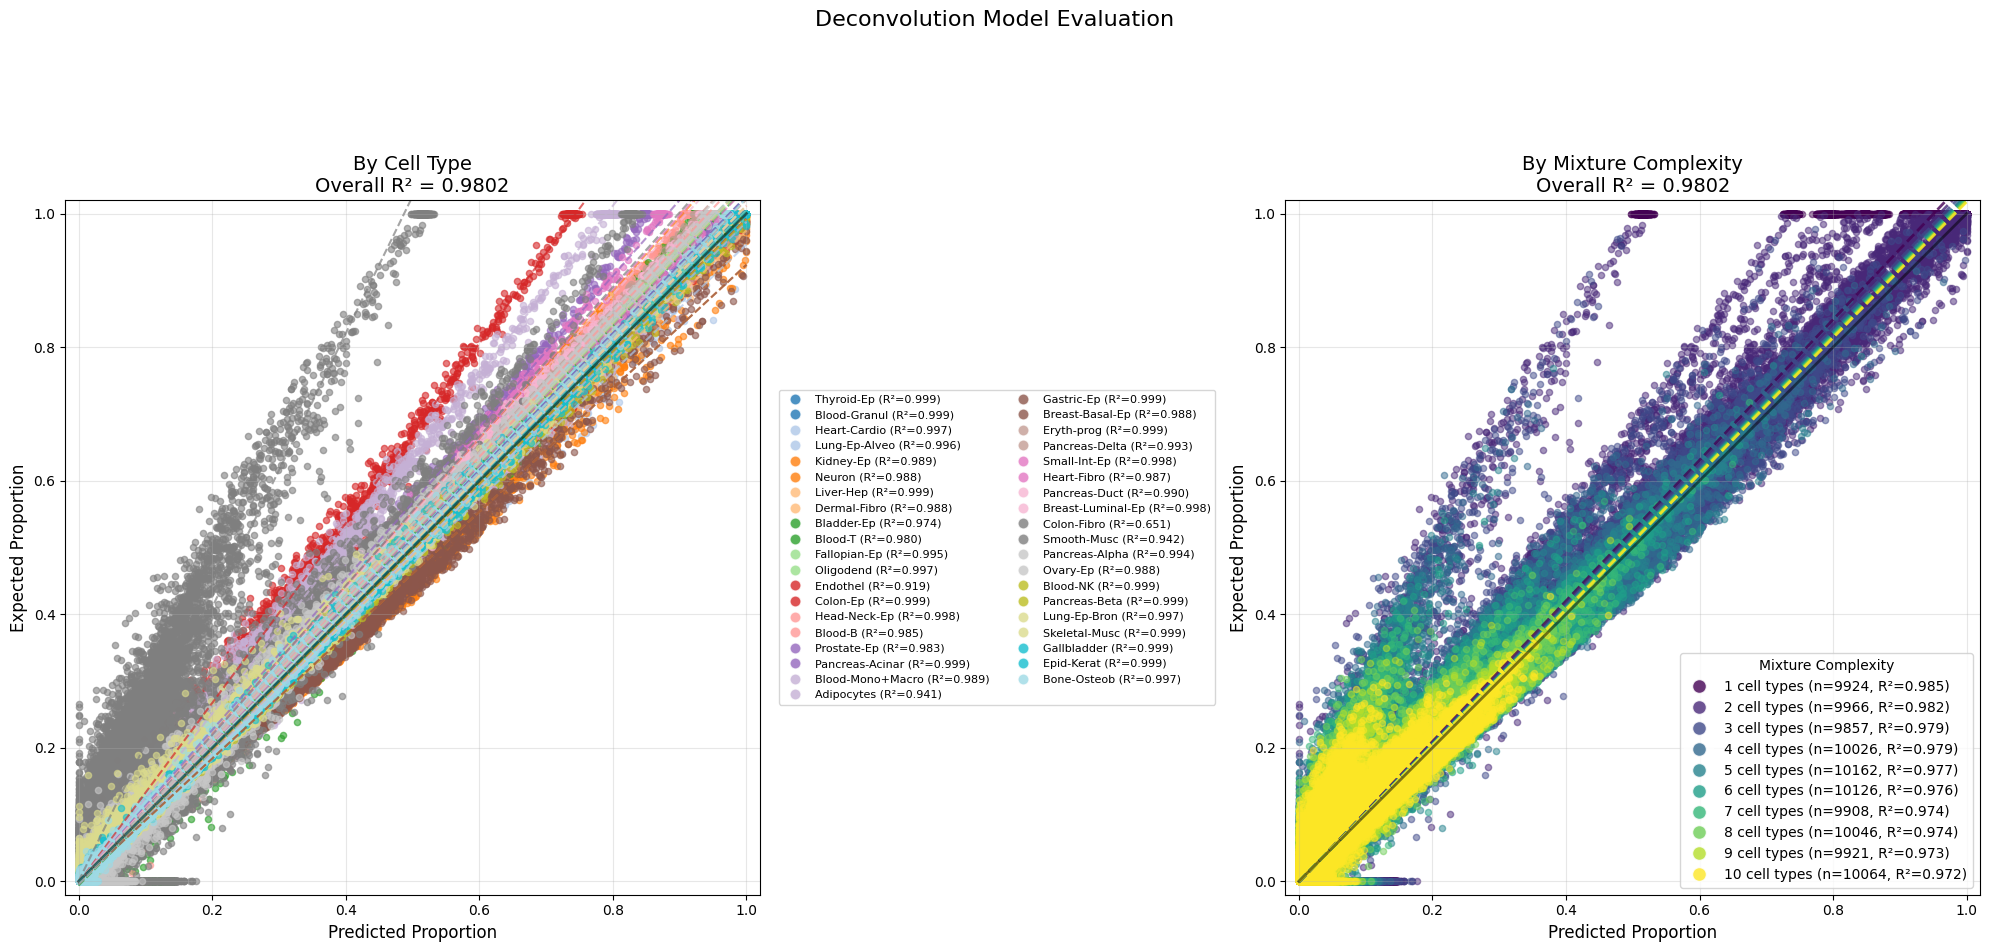

In [25]:
fig, all_metrics = plot_deconvolution_results(
    y_true=y_all_ft_selected,
    y_pred=pred_mixtures_nnls_ft_selected_test,
    labels_dict={int(k): v for k, v in labels_dict.items()},
)

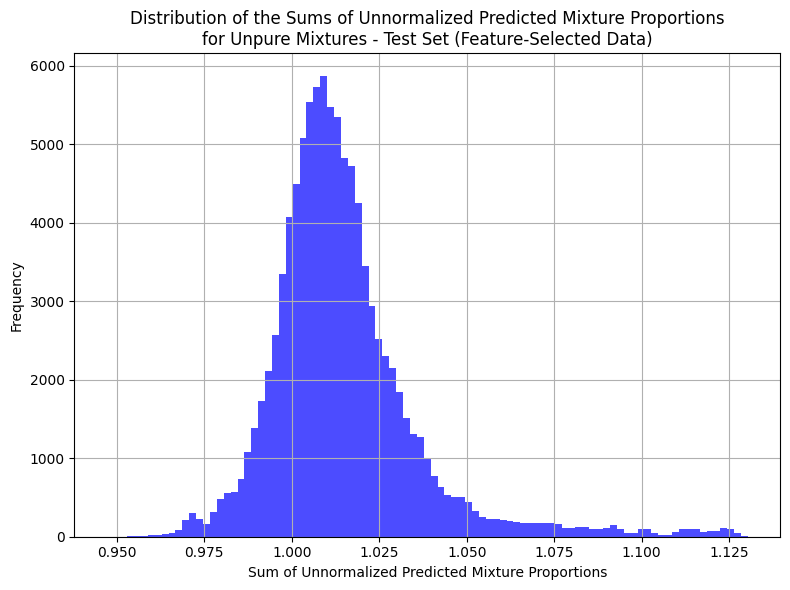

In [26]:
# Analysis of how hard the predictions had to be normalized to get good performance,
# by looking at the distribution of the sums of the unnormalized predicted mixture proportions
# across the samples in the test set of unpure mixtures

sums_unnorm_preds_ft_selected = pred_mixtures_unnormalized_nnls_ft_selected_test.sum(
    axis=1
)
plt.figure(figsize=(8, 6))
plt.hist(sums_unnorm_preds_ft_selected, bins="rice", color="blue", alpha=0.7)
plt.xlabel("Sum of Unnormalized Predicted Mixture Proportions")
plt.ylabel("Frequency")
plt.title(
    "Distribution of the Sums of Unnormalized Predicted Mixture Proportions\nfor Unpure Mixtures - Test Set (Feature-Selected Data)"
)
plt.grid()
plt.tight_layout()
plt.show()

We see that there is a significant part of the samples who do not sum to 1 nativaly, so we want to see if these specific samples are the ones for which the method performs the worst, and if there is a correlation between the sum of the predictions and the performance of the method.

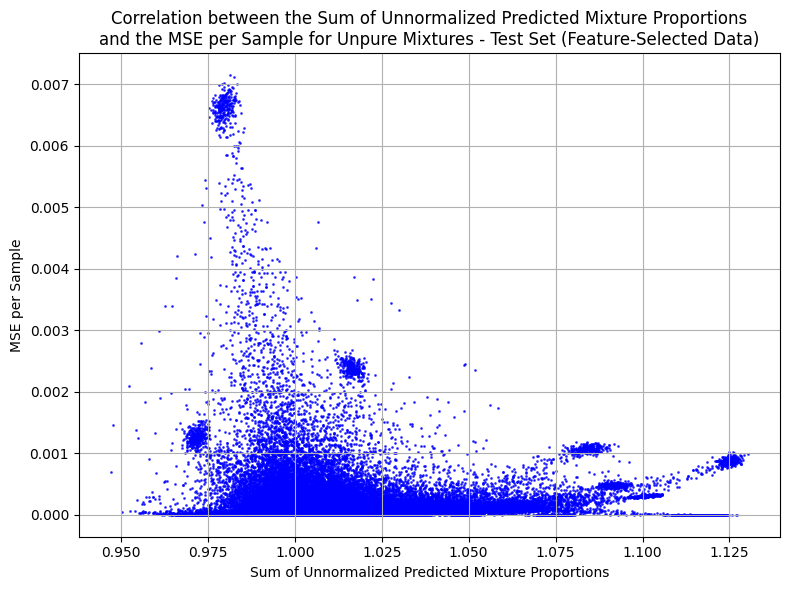

In [27]:
# compute the mse per sample on the test data for the unpure mixtures with feature selection,
# and see if there is a correlation between the mse and the sum of the unnormalized predicted mixture proportions
mse_per_sample_ft_selected = np.mean(
    (pred_mixtures_nnls_ft_selected_test - y_all_ft_selected) ** 2, axis=1
)

plt.figure(figsize=(8, 6))
plt.scatter(
    sums_unnorm_preds_ft_selected,
    mse_per_sample_ft_selected,
    color="blue",
    alpha=0.7,
    s=1,
)
plt.xlabel("Sum of Unnormalized Predicted Mixture Proportions")
plt.ylabel("MSE per Sample")
plt.title(
    "Correlation between the Sum of Unnormalized Predicted Mixture Proportions\nand the MSE per Sample for Unpure Mixtures - Test Set (Feature-Selected Data)"
)
plt.grid()
plt.tight_layout()
plt.show()

In [28]:
if False:
    TOP_K = 3
    PROPORTION_THRESHOLD = 0.10
    LIMIT_SUBSET_SIZE_TO_SHOW = 10000
    actual_n_points_to_show = min(
        LIMIT_SUBSET_SIZE_TO_SHOW, len(pred_mixtures_nnls_ft_selected_test)
    )

    selected_indexes_to_show = np.random.choice(
        len(pred_mixtures_nnls_ft_selected_test),
        size=actual_n_points_to_show,
        replace=False,
    )

    def format_label_summary(
        proportions: np.ndarray,
        top_k: int,
        threshold: float,
    ) -> tuple[str, str]:
        sorted_indices = np.argsort(proportions)[::-1]
        top_indices = sorted_indices[:top_k]
        threshold_indices = sorted_indices[proportions[sorted_indices] >= threshold]

        top_summary = "<br>".join(
            f"{labels_dict[str(idx)]}: {proportions[idx]:.4f}" for idx in top_indices
        )

        threshold_summary = "<br>".join(
            f"{labels_dict[str(idx)]}: {proportions[idx]:.4f}"
            for idx in threshold_indices
        )
        if not threshold_summary:
            threshold_summary = "None"

        return top_summary, threshold_summary

    mse_per_sample_ft_selected = np.mean(
        (
            pred_mixtures_nnls_ft_selected_test[selected_indexes_to_show]
            - y_all_ft_selected[selected_indexes_to_show]
        )
        ** 2,
        axis=1,
    )

    hover_rows = []
    for sample_idx, (ground_truth_mixture, predicted_mixture) in enumerate(
        zip(
            y_all_ft_selected[selected_indexes_to_show],
            pred_mixtures_nnls_ft_selected_test[selected_indexes_to_show],
        )
    ):
        gt_top_k_summary, gt_threshold_summary = format_label_summary(
            ground_truth_mixture,
            top_k=TOP_K,
            threshold=PROPORTION_THRESHOLD,
        )
        pred_top_k_summary, pred_threshold_summary = format_label_summary(
            predicted_mixture,
            top_k=TOP_K,
            threshold=PROPORTION_THRESHOLD,
        )
        hover_rows.append(
            [
                sample_idx,
                gt_top_k_summary,
                pred_top_k_summary,
                gt_threshold_summary,
                pred_threshold_summary,
            ]
        )

    fig = go.Figure(
        data=[
            go.Scatter(
                x=sums_unnorm_preds_ft_selected[selected_indexes_to_show],
                y=mse_per_sample_ft_selected,
                mode="markers",
                marker=dict(color="blue", size=2, opacity=0.7),
                customdata=np.array(hover_rows, dtype=object),
                hovertemplate=(
                    "Sample index: %{customdata[0]}<br>"
                    "Sum of unnormalized predictions: %{x:.4f}<br>"
                    "MSE per sample: %{y:.6f}<br><br>"
                    f"Top {TOP_K} ground-truth labels:<br>"
                    "%{customdata[1]}<br><br>"
                    f"Top {TOP_K} predicted labels:<br>"
                    "%{customdata[2]}<br><br>"
                    f"Ground-truth labels above {PROPORTION_THRESHOLD:.2f}:<br>"
                    "%{customdata[3]}<br><br>"
                    f"Predicted labels above {PROPORTION_THRESHOLD:.2f}:<br>"
                    "%{customdata[4]}"
                    "<extra></extra>"
                ),
            )
        ],
    )

    fig.update_layout(
        title=(
            "Correlation between the Sum of Unnormalized Predicted Mixture Proportions"
            "<br>and the MSE per Sample for Unpure Mixtures - Test Set "
            "(Feature-Selected Data)"
        ),
        xaxis_title="Sum of Unnormalized Predicted Mixture Proportions",
        yaxis_title="MSE per Sample",
        template="plotly_white",
        width=800,
        height=600,
    )

    fig.show()

### 5.2 PSLS: Probability Simplex Least Squares

Now we want to test if adding the constraint that the proportions must sum to 1 improves the performance of the method. In other terms, we want to solve the following optimization problem (PSLS stands for Probability Simplex Least Squares):

$$
\min_{w \in \mathbb{R}^c} ||P w - M||_2^2 \quad \text{subject to} \quad w_i \ge 0, \sum_{i=1}^c w_i = 1
$$

#### 5.2.2. Evaluation of the PSLS deconvolution method on feature selected vectors

In [29]:
psls_deconvolver = PSLSDeconvolver()
_ = psls_deconvolver.fit(X_pure_ft_selected_by_split["train"], y_pure_labels)

Compute the results on a subset of the test set

In [30]:
SUBSET_SIZE_TO_EVALUATE = 2000
actual_subset_size = min(
    SUBSET_SIZE_TO_EVALUATE, X_all_ft_selected_by_split["test"].shape[0]
)
subset_indexes = np.random.choice(
    X_all_ft_selected_by_split["test"].shape[0], size=actual_subset_size, replace=False
)

In [31]:
test_pred_fr_sel_psls_subset = psls_deconvolver.predict(
    X_all_ft_selected_by_split["test"][subset_indexes], method="cvxpy", n_workers=2
)

Predicting with PSLS in parallel: 100%|██████████| 20/20 [00:08<00:00,  2.29it/s]


In [32]:
compute_deconvolution_metrics_np(
    pred=test_pred_fr_sel_psls_subset,
    target=y_all_ft_selected[subset_indexes],
)

{'mae': 0.0031801319269859313,
 'mse': 0.0001544582084175359,
 'kl': 0.07480931879185308,
 'max_error': 0.5015451691932546,
 'cosine_sim': 0.9910249162562195}

Compute the predictions on the whole test set and evaluate the performance of the method.

In [33]:
test_pred_fr_sel_psls = psls_deconvolver.predict(
    X_all_ft_selected_by_split["test"], method="cvxpy", n_workers=4
)

Predicting with PSLS in parallel: 100%|██████████| 1000/1000 [06:14<00:00,  2.67it/s]


In [36]:
compute_deconvolution_metrics_np(
    pred=test_pred_fr_sel_psls,
    target=y_all_ft_selected,
)

{'mae': 0.0031879102730524556,
 'mse': 0.00016341759602345055,
 'kl': 0.07663383229829901,
 'max_error': 0.517212738230459,
 'cosine_sim': 0.9909124280849129}

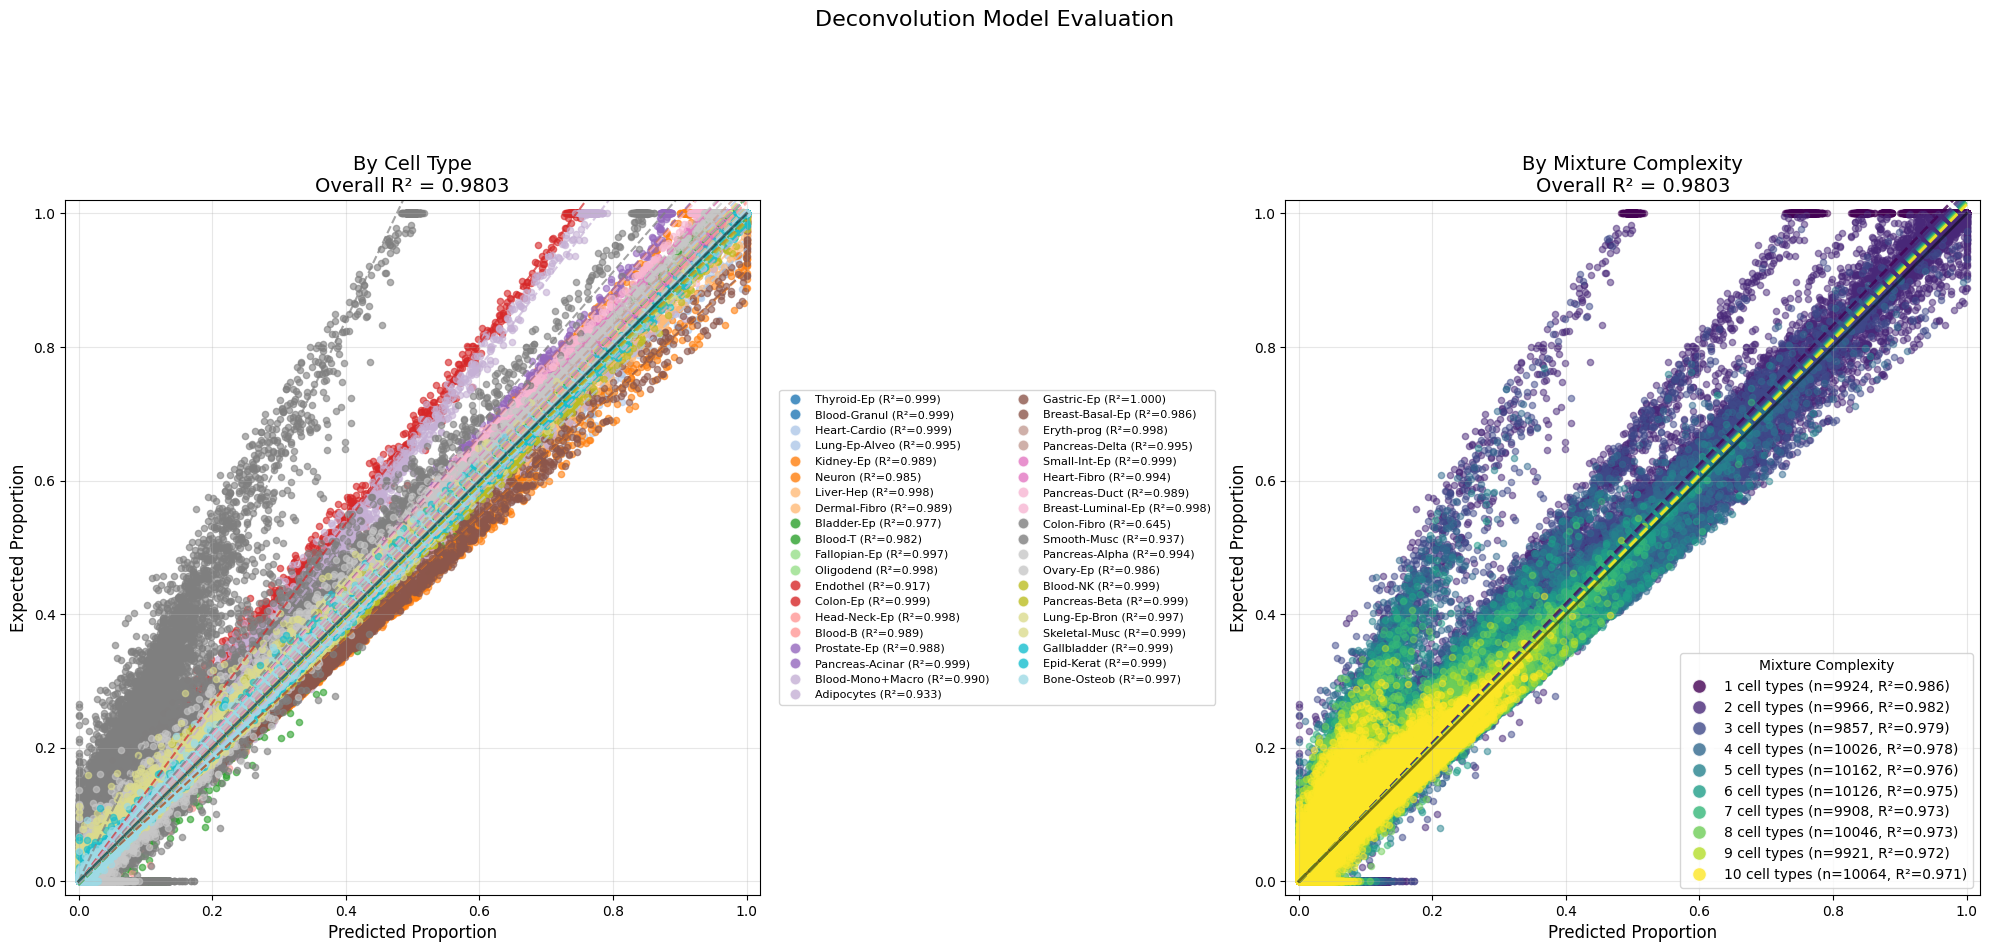

In [44]:
fig, all_metrics = plot_deconvolution_results(
    y_true=y_all_ft_selected,
    y_pred=test_pred_fr_sel_psls,
    labels_dict={int(k): v for k, v in labels_dict.items()},
)

## ENCODE Data experiment

In [34]:
# load the encode data sample
with open("../Data/mixtures/ENCFF020QAX_dmr_aggregated.pkl", "rb") as f:
    encode_sample_df = pickle.load(f)
encode_sample_matrix = encode_sample_df[PRED_COLUMNS].to_numpy()

ft_sel_mask = np.load("../Data/mixtures/features_mask_1.1_cutoff.npz")["features_mask"]
encode_sample_matrix_ft_selected = np.array(
    [
        encode_sample_matrix[i, j]
        for i in range(39)
        for j in range(39)
        if ft_sel_mask[i, j]
    ]
)
encode_sample_matrix_ft_selected.shape

(152,)

In [35]:
# compute the prediction for the encode sample with the NNLS deconvolver
encode_sample_pred_nnls, encode_sample_pred_unnorm, _ = (
    nnls_deconv_ft_selected.predict_single_sample(encode_sample_matrix_ft_selected)
)
np.save(
    "../Data/mixtures/ENCFF020QAX_dmr_aggregated_NNLS_ft_select_prediction.npy",
    encode_sample_pred,
)

NameError: name 'encode_sample_pred' is not defined

In [ ]:
# compute the prediction for the encode sample with the PSLS deconvolver
encode_sample_pred_psls = psls_deconvolver.predict_single_sample(
    encode_sample_matrix_ft_selected
)
np.save(
    "../Data/mixtures/ENCFF020QAX_dmr_aggregated_PSLS_ft_select_prediction.npy",
    encode_sample_pred_psls,
)

In [ ]:
plot_mixtures_pred_vs_true(
    ground_truth_mixture=np.ones(39),
    predicted_mixtures=[
        encode_sample_pred_nnls,
        encode_sample_pred_psls,
    ],
    predicted_mixture_labels=[
        "NNLS Deconvolver Prediction",
        "PSLS Deconvolver Prediction",
    ],
    title="Predicted Mixtures for ENCFF020QAX Sample vs Ground Truth Mixture",
)